# Comparação factorial 2×2: painel × contexto

Quatro *runs* sobre a **mesma população** e a **mesma referência**, num desenho 2×2: o **nível do painel** (comercial face a aberto) e o **contexto de jogo** (injectado ou não na prompt). Como `final_label` é independente da *run*, todas as quatro são calibráveis contra a mesma referência.

| | sem contexto | + contexto |
|---|---|---|
| **painel comercial** | Run 1 | Run 9 |
| **painel aberto** | Run 2 | Run 8 |

**O claude-3.5-haiku foi descontinuado a meio do estudo** e nunca chegou a correr na *run* 9, pelo que a célula comercial+contexto se avalia sobre 3 modelos comuns (ver abaixo).

In [2]:
%run 00_setup.ipynb

## Carregar a exportação `?run=all`
Exporte com `?run=all` e guarde como `analysis-export.zip`.

In [3]:
from sklearn.metrics import precision_recall_fscore_support as prf

# o desenho 2x2: nivel do painel (comercial/aberto) x contexto de jogo (sem/com)
RUNS = {1:"comercial/sem-ctx", 2:"aberto/sem-ctx", 8:"aberto/+ctx", 9:"comercial/+ctx"}

A = load("annotations.csv", run=None)
G = load("gold.csv", run=None)
M = load("meta.csv", run=None)

# o gold (final_label) e independente da run: as runs da populacao partilham o mesmo gold
adj = set(G[(G["runId"] == 1) & (G["pass"] == "open")]["individualId"])
print("runs:", RUNS)
print("revisoes adjudicadas (open):", len(adj))

runs: {1: 'comercial/sem-ctx', 2: 'aberto/sem-ctx', 8: 'aberto/+ctx', 9: 'comercial/+ctx'}
revisoes adjudicadas (open): 231


## Confirmar o desenho: mesma população e taxonomia
A comparação só é justa se as quatro *runs* partilharem população e taxonomia (o mesmo conjunto de 19 padrões e a mesma referência).

In [4]:
print(M[M["runId"].isin(RUNS)][["runId","populationId","taxonomyVersion"]].to_string(index=False))
assert M[M["runId"].isin(RUNS)]["populationId"].nunique() == 1, "populacoes diferentes"

 runId  populationId  taxonomyVersion
     9             1                2
     8             1                2
     2             1                2
     1             1                2


## A descontinuação do claude-3.5-haiku
O claude-3.5-haiku foi descontinuado no fornecedor a meio do estudo e nunca chegou a correr na *run* 9. Os restantes três (3) modelos comerciais completaram as revisões adjudicadas nas duas *runs*, pelo que o efeito do contexto no painel comercial se mede a paridade de 3 modelos (sem o claude dos dois lados). Confirme a cobertura:

In [5]:
r9 = A[(A["runId"] == 9) & (A["individualId"].isin(adj))]
print("cobertura por modelo na run 9 (de", len(adj), "revisoes adjudicadas):")
for m in sorted(r9["modelSlug"].unique()):
    print("  ", m.split("/")[-1], int(r9[r9["modelSlug"]==m]["individualId"].nunique()))
print("  claude-3.5-haiku 0  (descontinuado)")
SHARED_COMM = ["openai/gpt-4o-mini","google/gemini-2.5-flash-lite","deepseek/deepseek-chat-v3.1"]

cobertura por modelo na run 9 (de 231 revisoes adjudicadas):
   deepseek-chat-v3.1 231
   gemini-2.5-flash-lite 230
   gpt-4o-mini 231
  claude-3.5-haiku 0  (descontinuado)


## Funções de pontuação

In [6]:
def macro_micro(pred, run, reviews):
    """F1 macro (media por padrao) e micro (celulas agregadas) de pred contra o gold da run, nas reviews dadas."""
    gold = G[(G["runId"] == run) & (G["pass"] == "open")][["individualId","code","finalLabel"]]
    d = pred.merge(gold, on=["individualId","code"], how="inner")
    d = d[d["individualId"].isin(reviews)]
    if d.empty: return float("nan"), float("nan")
    d["yt"] = d["finalLabel"].astype(int); d["yp"] = d["present"].astype(int)
    fs = [prf(x["yt"], x["yp"], average="binary", pos_label=1, zero_division=0)[2] for _,x in d.groupby("code")]
    _,_,mic,_ = prf(d["yt"], d["yp"], average="binary", pos_label=1, zero_division=0)
    return round(float(np.mean(fs)),3), round(mic,3)

def run_scores(run, reviews):
    ann = A[A["runId"] == run]
    pm_mac, pm_mic = macro_micro(panel_majority(ann), run, reviews)
    best = ("", float("-inf"), float("nan"))
    for mdl in ann["modelSlug"].unique():
        mac, mic = macro_micro(ann[ann["modelSlug"]==mdl][["individualId","code","present"]], run, reviews)
        if not np.isnan(mac) and mac > best[1]: best = (mdl.split("/")[-1], mac, mic)
    return {"painel-macro":pm_mac, "painel-micro":pm_mic, "melhor-modelo":best[0], "melhor-macro":round(best[1],3)}

## O quadro 2×2 (face à referência, revisões adjudicadas)
Para cada *run*: F1 macro/micro da **maioria do painel** e o **melhor modelo isolado**. Entre níveis só são comparáveis o painel e o melhor-modelo (os modelos diferem); dentro do mesmo painel, os modelos alinham.

In [7]:
rows = {RUNS[r]: run_scores(r, adj) for r in RUNS}
tab = pd.DataFrame(rows).T[["painel-macro","painel-micro","melhor-modelo","melhor-macro"]]
print(tab.to_string())
print("\n[!] run 9: painel de 3 modelos (claude descontinuado); nao comparar a celula com a run 1 a 4 modelos -- ver a seccao a paridade de 3")

                  painel-macro painel-micro                melhor-modelo melhor-macro
comercial/sem-ctx         0.38        0.589             claude-3.5-haiku        0.694
aberto/sem-ctx           0.194        0.395  qwen3-next-80b-a3b-instruct        0.446
aberto/+ctx              0.114        0.267  qwen3-next-80b-a3b-instruct          0.4
comercial/+ctx           0.319        0.538        gemini-2.5-flash-lite        0.379

[!] run 9: painel de 3 modelos (claude descontinuado); nao comparar a celula com a run 1 a 4 modelos -- ver a seccao a paridade de 3


> **Efeito do nível do painel** (Run 1 face a Run 2): o painel comercial supera o aberto de forma clara. **Efeito do contexto** (Run 2 face a Run 8, final; Run 1 face a Run 9, provisório): injectar contexto de jogo *piorou* a detecção. A **pergunta de valor**: o *barato + contexto* (Run 8) não se aproxima do *caro sem contexto* (Run 1).

## Efeito do contexto, por modelo (dentro de cada painel)
Dentro do mesmo painel os modelos são os mesmos, logo a diferença por modelo isola o efeito do contexto.

In [8]:
def model_delta(rA, rB):
    out = []
    for m in sorted(A[A["runId"]==rA]["modelSlug"].unique()):
        a,_ = macro_micro(A[(A["runId"]==rA)&(A["modelSlug"]==m)][["individualId","code","present"]], rA, adj)
        b,_ = macro_micro(A[(A["runId"]==rB)&(A["modelSlug"]==m)][["individualId","code","present"]], rB, adj)
        out.append({"modelo":m.split("/")[-1], "sem-ctx":a, "+ctx":b, "delta":round(b-a,3) if not (np.isnan(a) or np.isnan(b)) else float("nan")})
    return pd.DataFrame(out)
print("-- painel ABERTO: run 2 -> run 8 (final) --"); print(model_delta(2,8).to_string(index=False))
print("\n-- painel COMERCIAL: run 1 -> run 9 (claude descontinuado = NaN; restantes 3 finais) --"); print(model_delta(1,9).to_string(index=False))

-- painel ABERTO: run 2 -> run 8 (final) --
                     modelo  sem-ctx  +ctx  delta
          deepseek-v4-flash    0.204 0.179 -0.025
     llama-3.3-70b-instruct    0.272 0.183 -0.089
               gpt-oss-120b    0.179 0.136 -0.043
qwen3-next-80b-a3b-instruct    0.446 0.400 -0.046

-- painel COMERCIAL: run 1 -> run 9 (claude descontinuado = NaN; restantes 3 finais) --
               modelo  sem-ctx  +ctx  delta
     claude-3.5-haiku    0.694   NaN    NaN
   deepseek-chat-v3.1    0.416 0.332 -0.084
gemini-2.5-flash-lite    0.485 0.379 -0.106
          gpt-4o-mini    0.318 0.248 -0.070


> Em ambos os painéis, o contexto **baixa** o F1 de praticamente todos os modelos. O `claude-3.5-haiku` aparece com `delta` `NaN` por ter sido descontinuado (sem contrapartida com contexto).

## Painel comercial a paridade de 3 modelos (claude excluído dos dois lados)
Como o claude só existe na *run* 1, o efeito do contexto ao nível do *painel* comercial mede-se sobre os 3 modelos comuns, para uma comparação justa e final.

In [9]:
def panel_shared(run):
    return run_scores_models(run, SHARED_COMM)
def run_scores_models(run, models):
    ann = A[(A["runId"]==run) & (A["modelSlug"].isin(models))]
    return macro_micro(panel_majority(ann), run, adj)
for run, lab in [(1,"sem contexto"),(9,"+ contexto")]:
    mac, mic = panel_shared(run)
    print(f"run {run} ({lab}) painel-3-comercial: macro={mac}  micro={mic}")

run 1 (sem contexto) painel-3-comercial: macro=0.407  micro=0.616
run 9 (+ contexto) painel-3-comercial: macro=0.319  micro=0.538


### O desenho factorial, em figura
As duas comparações justas do efeito do contexto — o painel aberto e o painel comercial a paridade de 3 modelos — com a célula comercial a 4 modelos como marcador de referência. A figura entra na secção 5.5 da dissertação.

gravado: figures/fig-factorial-2x2.png


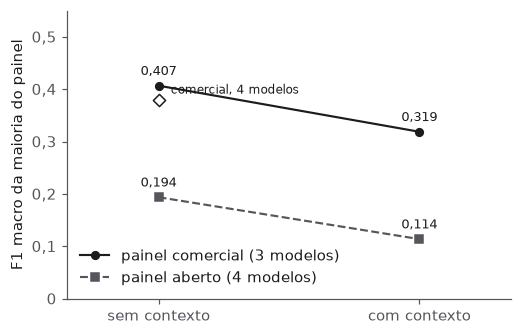

In [10]:
from matplotlib.ticker import FuncFormatter
plt = styled_plt()
ab = {r: run_scores(r, adj)["painel-macro"] for r in (2, 8)}
com3 = {r: run_scores_models(r, SHARED_COMM)[0] for r in (1, 9)}
com4 = run_scores(1, adj)["painel-macro"]
fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.plot([0, 1], [com3[1], com3[9]], marker="o", ms=5, ls="-", lw=1.4, color=INK, label="painel comercial (3 modelos)")
ax.plot([0, 1], [ab[2], ab[8]], marker="s", ms=5, ls="--", lw=1.4, color=MID, label="painel aberto (4 modelos)")
ax.scatter([0], [com4], marker="D", s=32, facecolors="white", edgecolors=INK, linewidths=1.0, zorder=3)
ax.annotate("comercial, 4 modelos", (0, com4), xytext=(8, 4), textcoords="offset points", fontsize=8)
for xx, vv in [(0, com3[1]), (1, com3[9]), (0, ab[2]), (1, ab[8])]:
    ax.annotate(virgula(vv), (xx, vv), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8.5)
ax.set_xticks([0, 1], ["sem contexto", "com contexto"])
ax.set_xlim(-0.35, 1.35)
ax.set_ylim(0, 0.55)
ax.set_ylabel("F1 macro da maioria do painel")
ax.yaxis.set_major_formatter(FuncFormatter(virgula))
ax.legend(loc="lower left")
save_fig(fig, "fig-factorial-2x2")

## Mecanismo: o contexto suprime a sinalização
Decomponha o F1 em precisão e revocação e conte as sinalizações. Se a revocação cai e o número de sinalizações desce, o contexto torna o painel mais silencioso (suprime/normaliza), em vez de o tornar ruidoso.

In [11]:
def PR(run, mdl):
    gold = G[(G["runId"]==run) & (G["pass"]=="open")][["individualId","code","finalLabel"]]
    ann = A[(A["runId"]==run) & (A["modelSlug"]==mdl)][["individualId","code","present"]]
    d = ann.merge(gold, on=["individualId","code"], how="inner"); d = d[d["individualId"].isin(adj)]
    d["yt"]=d["finalLabel"].astype(int); d["yp"]=d["present"].astype(int)
    ps,rs=[],[]
    for _,x in d.groupby("code"):
        p,r,_,_=prf(x["yt"],x["yp"],average="binary",pos_label=1,zero_division=0); ps.append(p); rs.append(r)
    return round(np.mean(ps),3), round(np.mean(rs),3), int(d["yp"].sum())
for rA,rB,lab in [(2,8,"aberto"),(1,9,"comercial 3-mod")]:
    models = SHARED_COMM if rB==9 else sorted(A[A.runId==rA].modelSlug.unique())
    print(f"-- {lab}: run {rA} -> run {rB} (precisao | revocacao | nº sinalizacoes) --")
    for m in models:
        pa,ra,fa=PR(rA,m); pb,rb,fb=PR(rB,m)
        print(f"  {m.split('/')[-1]:26s} P {pa:.3f}->{pb:.3f} | R {ra:.3f}->{rb:.3f} | sinal {fa}->{fb}")

-- aberto: run 2 -> run 8 (precisao | revocacao | nº sinalizacoes) --
  deepseek-v4-flash          P 0.518->0.474 | R 0.139->0.119 | sinal 92->69
  llama-3.3-70b-instruct     P 0.512->0.492 | R 0.198->0.118 | sinal 123->70
  gpt-oss-120b               P 0.477->0.375 | R 0.122->0.092 | sinal 84->69
  qwen3-next-80b-a3b-instruct P 0.657->0.540 | R 0.359->0.333 | sinal 185->193
-- comercial 3-mod: run 1 -> run 9 (precisao | revocacao | nº sinalizacoes) --
  gpt-4o-mini                P 0.554->0.450 | R 0.256->0.195 | sinal 163->148
  gemini-2.5-flash-lite      P 0.653->0.656 | R 0.405->0.285 | sinal 196->156
  deepseek-chat-v3.1         P 0.623->0.630 | R 0.325->0.245 | sinal 149->129


> A revocação cai em todos os modelos e as sinalizações descem na maioria: o contexto **suprime** a detecção (provavelmente por normalização, pois o modelo trata o padrão como esperado para o jogo), e não a torna ruidosa.

## Não é artefacto de seguir o painel (teste contra a referência cega)
A referência aberta foi semeada das *runs* SEM contexto, pelo que poderia favorecê-las. Para o excluir, repita a comparação contra a referência CEGA (adjudicada sem painel à vista, logo sem qualquer influência do painel). Se o contexto ainda degrada, o efeito é real. Ressalva: a referência cega é pequena (n=35), pelo que é uma confirmação direccional.

In [12]:
blind = set(G[(G["runId"]==1) & (G["pass"]=="blind")]["individualId"])
def micro_blind(run, mdl):
    gold = G[(G["runId"]==run) & (G["pass"]=="blind")][["individualId","code","finalLabel"]]
    ann = A[(A["runId"]==run) & (A["modelSlug"]==mdl)][["individualId","code","present"]]
    d = ann.merge(gold, on=["individualId","code"], how="inner"); d = d[d["individualId"].isin(blind)]
    if d.empty: return float("nan")
    _,_,f,_=prf(d["finalLabel"].astype(int), d["present"].astype(int), average="binary", pos_label=1, zero_division=0)
    return round(f,3)
print("revisoes no gold cego:", len(blind))
for rA,rB,lab in [(2,8,"aberto"),(1,9,"comercial 3-mod")]:
    models = SHARED_COMM if rB==9 else sorted(A[A.runId==rA].modelSlug.unique())
    print(f"-- {lab} micro-F1 vs gold CEGO: run {rA} -> run {rB} --")
    for m in models:
        print(f"  {m.split('/')[-1]:26s} {micro_blind(rA,m)} -> {micro_blind(rB,m)}")

revisoes no gold cego: 35
-- aberto micro-F1 vs gold CEGO: run 2 -> run 8 --
  deepseek-v4-flash          0.214 -> 0.167
  llama-3.3-70b-instruct     0.353 -> 0.267
  gpt-oss-120b               0.296 -> 0.24
  qwen3-next-80b-a3b-instruct 0.364 -> 0.267
-- comercial 3-mod micro-F1 vs gold CEGO: run 1 -> run 9 --
  gpt-4o-mini                0.485 -> 0.356
  gemini-2.5-flash-lite      0.5 -> 0.424
  deepseek-chat-v3.1         0.4 -> 0.345


> Contra o *gold* cego (sem qualquer influência do painel), o contexto continua a degradar todos os modelos medidos, pelo que a queda não é artefacto de a referência ter sido semeada das *runs* sem contexto.

## O eixo da taxonomia e da prompt: v1 → v2
Antes do desenho factorial, a mesma população foi anotada pelos mesmos dois painéis sob a **taxonomia v1 e a prompt simples** (*runs* 3 e 4). Como os 19 códigos são idênticos nas duas versões e o `final_label` é uma propriedade da revisão, estas execuções são calibráveis contra a mesma referência, e os pares (3→1) e (4→2) medem o efeito da evolução conjunta taxonomia+prompt, com o painel e a população fixos. Ressalva: mudaram dois parâmetros em conjunto (a taxonomia E a prompt), pelo que o efeito é do par, e não de cada um isoladamente.

In [13]:
assert set(A[A["runId"]==3]["code"].unique()) == set(A[A["runId"]==1]["code"].unique()), "codigos diferentes entre taxonomias"

def version_delta(r_old, r_new):
    out = []
    for m in sorted(A[A["runId"]==r_old]["modelSlug"].unique()):
        a,_ = macro_micro(A[(A["runId"]==r_old)&(A["modelSlug"]==m)][["individualId","code","present"]], r_old, adj)
        b,_ = macro_micro(A[(A["runId"]==r_new)&(A["modelSlug"]==m)][["individualId","code","present"]], r_new, adj)
        out.append({"modelo": m.split("/")[-1], "v1": a, "v2": b, "delta": round(b-a,3)})
    pa = macro_micro(panel_majority(A[A["runId"]==r_old]), r_old, adj)
    pb = macro_micro(panel_majority(A[A["runId"]==r_new]), r_new, adj)
    out.append({"modelo": "painel (maioria)", "v1": pa[0], "v2": pb[0], "delta": round(pb[0]-pa[0],3)})
    return pd.DataFrame(out)

vd_com, vd_ab = version_delta(3,1), version_delta(4,2)
print("-- painel COMERCIAL: run 3 (v1/simple) -> run 1 (v2/enhanced) --")
print(vd_com.to_string(index=False))
print()
print("-- painel ABERTO: run 4 (v1/simple) -> run 2 (v2/enhanced) --")
print(vd_ab.to_string(index=False))

-- painel COMERCIAL: run 3 (v1/simple) -> run 1 (v2/enhanced) --
               modelo    v1    v2  delta
     claude-3.5-haiku 0.345 0.694  0.349
   deepseek-chat-v3.1 0.258 0.416  0.158
gemini-2.5-flash-lite 0.272 0.485  0.213
          gpt-4o-mini 0.205 0.318  0.113
     painel (maioria) 0.198 0.380  0.182

-- painel ABERTO: run 4 (v1/simple) -> run 2 (v2/enhanced) --
                     modelo    v1    v2  delta
          deepseek-v4-flash 0.209 0.204 -0.005
     llama-3.3-70b-instruct 0.248 0.272  0.024
               gpt-oss-120b 0.214 0.179 -0.035
qwen3-next-80b-a3b-instruct 0.297 0.446  0.149
           painel (maioria) 0.147 0.194  0.047


> A variação de maior amplitude entre as analisadas: a evolução v1→v2 quase duplicou a validade do painel comercial (macro 0,198→0,380) e melhorou a do aberto (0,147→0,194), com uma interacção clara: os modelos capazes beneficiam muito mais da instrução rica (claude +0,349; qwen +0,149) do que os fracos (deepseek e gpt-oss estagnam ou pioram). Do lado da fiabilidade, o α do TM-1 subiu de 0,281/0,394 (v1) para 0,764/0,670 (v2), enquanto o PM-1 ficou estável: o enriquecimento resolveu sobretudo a ambiguidade dos padrões temporais.

### A evolução v1→v2, em figura
Quatro linhas, cada uma um salto de v1 (ponto aberto) para v2 (ponto cheio): a maioria e o melhor modelo, em cada painel. A figura entra na secção 5.5 da dissertação.

gravado: figures/fig-versao-taxonomia.png


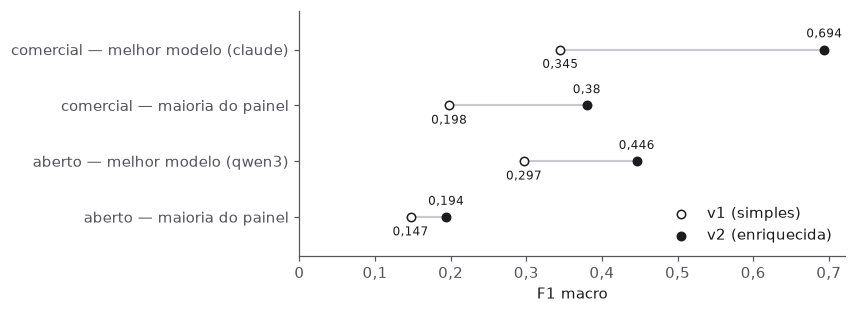

In [14]:
from matplotlib.ticker import FuncFormatter
plt = styled_plt()
def linhas_de(lab, vd):
    pan = vd[vd["modelo"] == "painel (maioria)"].iloc[0]
    top = vd[vd["modelo"] != "painel (maioria)"].sort_values("v2").iloc[-1]
    return [(f"{lab} — maioria do painel", pan["v1"], pan["v2"]),
            (f"{lab} — melhor modelo ({top['modelo'].split('-')[0]})", top["v1"], top["v2"])]
linhas = linhas_de("aberto", vd_ab) + linhas_de("comercial", vd_com)   # comercial no topo
fig, ax = plt.subplots(figsize=(6.4, 2.9))
for y, (lab, v1, v2) in enumerate(linhas):
    ax.plot([v1, v2], [y, y], color=FAINT, lw=1.4, zorder=1)
    ax.scatter([v1], [y], s=30, facecolors="white", edgecolors=INK, linewidths=1.0, zorder=2, label="v1 (simples)" if y == 0 else None)
    ax.scatter([v2], [y], s=30, color=INK, zorder=2, label="v2 (enriquecida)" if y == 0 else None)
    ax.annotate(virgula(v1), (v1, y), xytext=(0, -12), textcoords="offset points", ha="center", fontsize=8)
    ax.annotate(virgula(v2), (v2, y), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)
ax.set_yticks(range(len(linhas)), [l for l, _, _ in linhas])
ax.set_xlabel("F1 macro")
ax.xaxis.set_major_formatter(FuncFormatter(virgula))
ax.set_xlim(0, None)
ax.set_ylim(-0.7, len(linhas) - 0.3)
ax.legend(loc="lower right")
save_fig(fig, "fig-versao-taxonomia")

## A direcção da adjudicação em todas as configurações
A leitura «o painel falha por omissão, nunca por excesso» foi estabelecida na *run* 8. Generaliza-se? Deriva-se a direcção para as seis execuções calibráveis e decompõem-se as substituições em adições (painel ausente, autor presente) e remoções (painel presente, autor ausente). Nas *runs* que não foram adjudicadas, a direcção é um exercício hipotético, o que aqui não prejudica: a pergunta é sobre o comportamento do painel, e não sobre o adjudicador.

In [15]:
rows = []
for run in [1, 2, 3, 4, 8, 9]:
    m = panel_majority(A[A["runId"]==run]).rename(columns={"present":"majority"})
    gold = G[(G["runId"]==run) & (G["pass"]=="open")][["individualId","code","finalLabel"]]
    d = gold.merge(m, on=["individualId","code"], how="inner")
    repl = int((d["finalLabel"] != d["majority"]).sum())
    adds = int(((~d["majority"]) & d["finalLabel"]).sum())
    rows.append({"run": run, "substituicoes": repl, "adicoes": adds, "remocoes": repl - adds})
t = pd.DataFrame(rows)
print(t.to_string(index=False))
print(f"\ntotal: {t['substituicoes'].sum()} substituicoes, {t['remocoes'].sum()} remocoes ({100*t['remocoes'].sum()/t['substituicoes'].sum():.1f}%)")

 run  substituicoes  adicoes  remocoes
   1            184      179         5
   2            236      234         2
   3            267      261         6
   4            272      265         7
   8            263      263         0
   9            199      195         4

total: 1421 substituicoes, 24 remocoes (1.7%)


> Em cerca de 1 400 substituições acumuladas nas seis configurações (dois níveis de painel, duas versões de taxonomia/prompt, com e sem contexto), as remoções são residuais: o padrão «preciso mas pouco sensível, falha por omissão» não é uma propriedade da execução de referência, é uma propriedade de todas as configurações avaliadas.

## Robustez ao tamanho do painel (*leave-one-out*)
Porquê 4 modelos e não 3? Deixe cair cada modelo, à vez, e observe como a maioria do painel se comporta, nas duas *runs* de cobertura completa. A ordenação (comercial > aberto) deve manter-se, e o que mais mexe deve ser *qual* modelo cai, e não quantos.

In [16]:
loo = []
for run, lab in [(1,"comercial"),(2,"aberto")]:
    models = sorted(A[A["runId"]==run]["modelSlug"].unique())
    loo.append({"painel": lab, "config": "4 modelos (3-de-4)", "macro": run_scores_models(run, models)[0], "base": True})
    print(f"run {run} ({lab}): 4 modelos (3-de-4) macro = {loo[-1]['macro']}")
    for drop in models:
        sub = [m for m in models if m != drop]
        loo.append({"painel": lab, "config": "sem " + drop.split("/")[-1], "macro": run_scores_models(run, sub)[0], "base": False})
        print(f"   sem {drop.split('/')[-1]:26s} (3 modelos, 2-de-3) macro = {loo[-1]['macro']}")
    print()
loo = pd.DataFrame(loo)

run 1 (comercial): 4 modelos (3-de-4) macro = 0.38
   sem claude-3.5-haiku           (3 modelos, 2-de-3) macro = 0.407
   sem deepseek-chat-v3.1         (3 modelos, 2-de-3) macro = 0.488
   sem gemini-2.5-flash-lite      (3 modelos, 2-de-3) macro = 0.448
   sem gpt-4o-mini                (3 modelos, 2-de-3) macro = 0.487

run 2 (aberto): 4 modelos (3-de-4) macro = 0.194
   sem deepseek-v4-flash          (3 modelos, 2-de-3) macro = 0.275
   sem llama-3.3-70b-instruct     (3 modelos, 2-de-3) macro = 0.206
   sem gpt-oss-120b               (3 modelos, 2-de-3) macro = 0.289
   sem qwen3-next-80b-a3b-instruct (3 modelos, 2-de-3) macro = 0.182



> A ordenação é invariante (qualquer painel comercial de 3 supera qualquer aberto de 3), pelo que o efeito do nível não depende do tamanho. O que sobe ao passar de 4 para 3 é o *limiar* (de três em quatro para dois em três, mais permissivo), e não a contagem. E deixar cair o **pior** modelo ajuda mais do que deixar cair o melhor: o valor concentra-se no melhor membro. Logo, 3 face a 4 não é determinante; a qualidade do modelo e o limiar pesam mais.

### A composição do painel, em figura
Um ponto por configuração, com a linha de base a 4 modelos como losango: os dois grupos não se tocam, e dentro de cada grupo o que mais mexe é *qual* modelo cai. A figura entra na secção 5.5 da dissertação.

gravado: figures/fig-composicao-painel.png


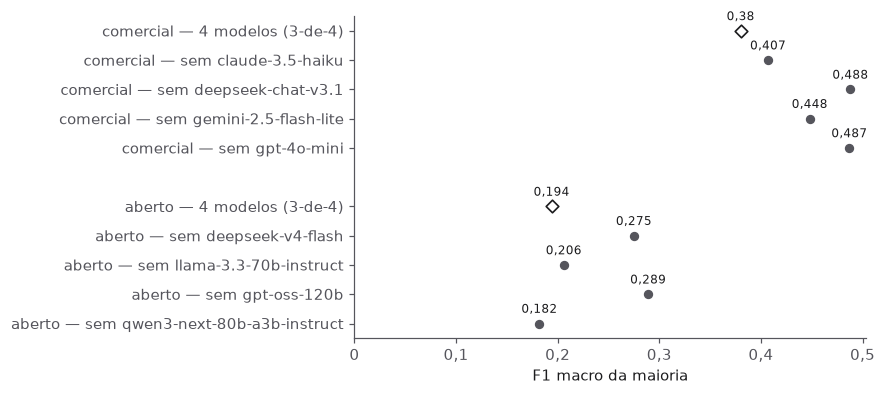

In [17]:
from matplotlib.ticker import FuncFormatter
plt = styled_plt()
fig, ax = plt.subplots(figsize=(6.0, 3.8))
ypos, ylabels, y = [], [], 0
for lab in ["aberto", "comercial"]:
    grp = loo[loo["painel"] == lab].iloc[::-1]   # base no topo do grupo
    for r in grp.itertuples():
        if r.base:
            ax.scatter([r.macro], [y], marker="D", s=34, facecolors="white", edgecolors=INK, linewidths=1.1, zorder=2)
        else:
            ax.scatter([r.macro], [y], s=26, color=MID, zorder=2)
        ax.annotate(virgula(r.macro), (r.macro, y), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8)
        ypos.append(y); ylabels.append(f"{r.painel} — {r.config}")
        y += 1
    y += 1
ax.set_yticks(ypos, ylabels)
ax.set_xlabel("F1 macro da maioria")
ax.xaxis.set_major_formatter(FuncFormatter(virgula))
ax.set_xlim(0, None)
save_fig(fig, "fig-composicao-painel")

## Divergência entre painéis (sem *gold*)
Quantas células a maioria de cada painel decide de forma diferente, sem necessitar da referência. Mede o quão diferentes são os dois instrumentos.

In [18]:
def maj_series(run, reviews):
    return panel_majority(A[(A["runId"]==run) & (A["individualId"].isin(reviews))]).set_index(["individualId","code"])["present"]
j = pd.concat([maj_series(1,adj).rename("comercial"), maj_series(2,adj).rename("aberto")], axis=1).dropna()
print(f"divergencia comercial(run1) vs aberto(run2): {int((j['comercial']!=j['aberto']).sum())} / {len(j)} celulas adjudicadas")

divergencia comercial(run1) vs aberto(run2): 70 / 4389 celulas adjudicadas
